___

<a href='http://www.pieriandata.com'> <img src='../Pierian_Data_Logo.png' /></a>
___

# Finance Data Project 

In this data project we will focus on exploratory data analysis of stock prices. Keep in mind, this project is just meant to practice your visualization and pandas skills, it is not meant to be a robust financial analysis or be taken as financial advice.
____
** NOTE: This project is extremely challenging because it will introduce a lot of new concepts and have you looking things up on your own (we'll point you in the right direction) to try to solve the tasks issued. Feel free to just go through the solutions lecture notebook and video as a "walkthrough" project if you don't want to have to look things up yourself. You'll still learn a lot that way! **
____
We'll focus on bank stocks and see how they progressed throughout the [financial crisis](https://en.wikipedia.org/wiki/Financial_crisis_of_2007%E2%80%9308) all the way to early 2016.

## Get the Data

In this section we will learn how to use pandas to directly read data from Google finance using pandas!

First we need to start with the proper imports, which we've already laid out for you here.

*Note: [You'll need to install pandas-datareader for this to work!](https://github.com/pydata/pandas-datareader) Pandas datareader allows you to [read stock information directly from the internet](http://pandas.pydata.org/pandas-docs/stable/remote_data.html) Use these links for install guidance (**pip install pandas-datareader**), or just follow along with the video lecture.*

### The Imports

Already filled out for you.

In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt

## Data

We need to get data using pandas datareader. We will get stock information for the following banks:
*  Bank of America
* CitiGroup
* Goldman Sachs
* JPMorgan Chase
* Morgan Stanley
* Wells Fargo

** Figure out how to get the stock data from Jan 1st 2006 to Jan 1st 2016 for each of these banks. Set each bank to be a separate dataframe, with the variable name for that bank being its ticker symbol. This will involve a few steps:**
1. Use datetime to set start and end datetime objects.
2. Figure out the ticker symbol for each bank.
2. Figure out how to use datareader to grab info on the stock.

** Use [this documentation page](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html) for hints and instructions (it should just be a matter of replacing certain values. Use google finance as a source, for example:**
    
    # Bank of America
    BAC = data.DataReader("BAC", 'google', start, end)

### WARNING: MAKE SURE TO CHECK THE LINK ABOVE FOR THE LATEST WORKING API. "google" MAY NOT ALWAYS WORK. 
------------
### We also provide pickle file in the article lecture right before the video lectures.

In [6]:
# Import libraries
import yfinance as yf
import pandas as pd

# Set date range
start = "2006-01-01"
end = "2016-01-01"


In [7]:
tickers = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']


In [8]:
BAC = yf.download("BAC", start=start, end=end)
C = yf.download("C", start=start, end=end)
GS = yf.download("GS", start=start, end=end)
JPM = yf.download("JPM", start=start, end=end)
MS = yf.download("MS", start=start, end=end)
WFC = yf.download("WFC", start=start, end=end)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [9]:
BAC.head()


Price,Close,High,Low,Open,Volume
Ticker,BAC,BAC,BAC,BAC,BAC
Date,,,,,
2006-01-03,30.487936,30.552693,29.885689,30.384321,16296700
2006-01-04,30.164150,30.591551,30.079965,30.436132,17757900
2006-01-05,30.202997,30.326038,29.995773,30.164144,14970700
2006-01-06,30.157661,30.377838,30.015194,30.306604,12599800
2006-01-09,30.177099,30.416705,30.021682,30.254810,15619400


** Create a list of the ticker symbols (as strings) in alphabetical order. Call this list: tickers**

In [10]:
tickers = ['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']
tickers = sorted(tickers)
print(tickers)

['BAC', 'C', 'GS', 'JPM', 'MS', 'WFC']


** Use pd.concat to concatenate the bank dataframes together to a single data frame called bank_stocks. Set the keys argument equal to the tickers list. Also pay attention to what axis you concatenate on.**

In [11]:
bank_stocks = pd.concat([BAC, C, GS, JPM, MS, WFC],  axis=1,  keys=tickers)

In [12]:
bank_stocks

BAC                                                      C  \
Price           Close       High        Low       Open    Volume       Close   
Ticker            BAC        BAC        BAC        BAC       BAC           C   
Date                                                                           
2006-01-03  30.487936  30.552693  29.885689  30.384321  16296700  315.803680   
2006-01-04  30.164150  30.591551  30.079965  30.436132  17757900  309.973145   
2006-01-05  30.202997  30.326038  29.995773  30.164144  14970700  311.510803   
2006-01-06  30.157661  30.377838  30.015194  30.306604  12599800  311.510803   
2006-01-09  30.177099  30.416705  30.021682  30.254810  15619400  310.037292   
...               ...        ...        ...        ...       ...         ...   
2015-12-24  13.793182  13.881036  13.753248  13.833116  29369400   39.169121   
2015-12-28  13.681365  13.761233  13.561564  13.753246  41777500   38.923885   
2015-12-29  13.801168  13.857076  13.705326  13.777208  45670400   39.369766   
2015-12-30  13.617471  13.769220  13.609485  13.737274  35066400   38.864449   
2015-12-31  13.441761  13.633444  13.441761  13.585523  47153000   38.455734   

                                                          ...         MS  \
Price             High         Low        Open    Volume  ...      Close   
Ticker               C           C           C         C  ...         MS   
Date                                                      ...              
2006-01-03  316.380311  308.243365  313.945639   1537600  ...  31.349619   
2006-01-04  314.586229  309.780941  313.048541   1870960  ...  31.371130   
2006-01-05  312.535916  310.101244  310.357522   1143160  ...  31.457169   
2006-01-06  313.304770  308.819834  313.176621   1370210  ...  31.489416   
2006-01-09  312.279761  309.460662  311.382778   1680740  ...  31.822739   
...                ...         ...         ...       ...  ...        ...   
2015-12-24   39.362330   38.975914   38.998207   4671200  ...  24.334864   
2015-12-28   39.065074   38.611779   39.065074   8761700  ...  24.102602   
2015-12-29   39.548113   39.191422   39.206282  10155100  ...  24.387310   
2015-12-30   39.340036   38.827294   39.265727   8763300  ...  24.147562   
2015-12-31   38.931322   38.455734   38.693528  11281800  ...  23.832888   

                                                            WFC             \
Price            High        Low       Open   Volume      Close       High   
Ticker             MS         MS         MS       MS        WFC        WFC   
Date                                                                         
2006-01-03  31.446394  30.505529  30.736711  5377000  18.379139  18.422351   
2006-01-04  31.871133  31.371130  31.559304  7977800  18.165968  18.333050   
2006-01-05  31.500181  31.193727  31.478675  5778000  18.145802  18.180370   
2006-01-06  31.639954  31.209844  31.596944  6889800  18.252392  18.307126   
2006-01-09  31.876504  31.516286  31.521663  4144500  18.249514  18.335937   
...               ...        ...        ...      ...        ...        ...   
2015-12-24  24.507185  24.304894  24.402294  2798200  41.133892  41.336485   
2015-12-28  24.244957  23.937774  24.244957  5420300  41.028851  41.103884   
2015-12-29  24.499695  24.222482  24.304895  6388200  41.486561  41.531580   
2015-12-30  24.462239  24.125086  24.349853  5057200  41.186417  41.501563   
2015-12-31  24.200008  23.802919  23.907811  8154300  40.788731  41.231434   

                                            
Price             Low       Open    Volume  
Ticker            WFC        WFC       WFC  
Date                                        
2006-01-03  17.972954  18.206295  11016400  
2006-01-04  18.070903  18.321527  10870000  
2006-01-05  18.039213  18.148682  10158000  
2006-01-06  18.082428  18.194777   8403800  
2006-01-09  18.180376  18.249514   5619600  
...               ...        ...       ...  
2015-12-24  41.051354  41.246445   4999400  
2015-12-28

** Set the column name levels (this is filled out for you):**

In [13]:
bank_stocks.columns.nlevels

3

In [14]:
bank_stocks.columns.names = ['Bank Ticker', 'Stock Info', 'Ticker']

** Check the head of the bank_stocks dataframe.**

In [15]:
bank_stocks.head()

Bank Ticker        BAC                                                      C  \
Stock Info       Close       High        Low       Open    Volume       Close   
Ticker             BAC        BAC        BAC        BAC       BAC           C   
Date                                                                            
2006-01-03   30.487936  30.552693  29.885689  30.384321  16296700  315.803680   
2006-01-04   30.164150  30.591551  30.079965  30.436132  17757900  309.973145   
2006-01-05   30.202997  30.326038  29.995773  30.164144  14970700  311.510803   
2006-01-06   30.157661  30.377838  30.015194  30.306604  12599800  311.510803   
2006-01-09   30.177099  30.416705  30.021682  30.254810  15619400  310.037292   

Bank Ticker                                               ...         MS  \
Stock Info         High         Low        Open   Volume  ...      Close   
Ticker                C           C           C        C  ...         MS   
Date                                                      ...              
2006-01-03   316.380311  308.243365  313.945639  1537600  ...  31.349619   
2006-01-04   314.586229  309.780941  313.048541  1870960  ...  31.371130   
2006-01-05   312.535916  310.101244  310.357522  1143160  ...  31.457169   
2006-01-06   313.304770  308.819834  313.176621  1370210  ...  31.489416   
2006-01-09   312.279761  309.460662  311.382778  1680740  ...  31.822739   

Bank Ticker                                                  WFC             \
Stock Info        High        Low       Open   Volume      Close       High   
Ticker              MS         MS         MS       MS        WFC        WFC   
Date                                                                          
2006-01-03   31.446394  30.505529  30.736711  5377000  18.379139  18.422351   
2006-01-04   31.871133  31.371130  31.559304  7977800  18.165968  18.333050   
2006-01-05   31.500181  31.193727  31.478675  5778000  18.145802  18.180370   
2006-01-06   31.639954  31.209844  31.596944  6889800  18.252392  18.307126   
2006-01-09   31.876504  31.516286  31.521663  4144500  18.249514  18.335937   

Bank Ticker                                  
Stock Info         Low       Open    Volume  
Ticker             WFC        WFC       WFC  
Date                                         
2006-01-03   17.972954  18.206295  11016400  
2006-01-04   18.070903  18.321527  10870000  
2006-01-05   18.039213  18.148682  10158000  
2006-01-06   18.082428  18.194777   8403800  
2006-01-09   18.180376  18.249514   5619600  

[5 rows x 30 columns]

# EDA

Let's explore the data a bit! Before continuing, I encourage you to check out the documentation on [Multi-Level Indexing](http://pandas.pydata.org/pandas-docs/stable/advanced.html) and [Using .xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html).
Reference the solutions if you can not figure out how to use .xs(), since that will be a major part of this project.

** What is the max Close price for each bank's stock throughout the time period?**

In [16]:
bank_stocks.xs('Close', level='Stock Info', axis=1).max().droplevel(1)

Bank Ticker
BAC     36.870285
C      376.505249
GS     182.299454
JPM     52.581150
MS      49.144009
WFC     43.327572
dtype: float64

** Create a new empty DataFrame called returns. This dataframe will contain the returns for each bank's stock. returns are typically defined by:**

$$r_t = \frac{p_t - p_{t-1}}{p_{t-1}} = \frac{p_t}{p_{t-1}} - 1$$

In [17]:
returns = pd.DataFrame()


** We can use pandas pct_change() method on the Close column to create a column representing this return value. Create a for loop that goes and for each Bank Stock Ticker creates this returns column and set's it as a column in the returns DataFrame.**

In [18]:
for tick in tickers:
    returns[tick + ' Return'] = bank_stocks[tick]['Close'].pct_change()

In [19]:
returns.head()

,BAC Return,C Return,GS Return,JPM Return,MS Return,WFC Return
Date,,,,,,
2006-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2006-01-04,-0.010620,-0.018463,-0.013813,-0.005772,0.000686,-0.011599
2006-01-05,0.001288,0.004961,-0.000393,0.003028,0.002743,-0.001110
2006-01-06,-0.001501,0.000000,0.014169,0.007046,0.001025,0.005874
2006-01-09,0.000645,-0.004730,0.012031,0.016242,0.010585,-0.000158


** Create a pairplot using seaborn of the returns dataframe. What stock stands out to you? Can you figure out why?**

In [20]:
import seaborn as sns

In [21]:
sns.set_style("whitegrid")

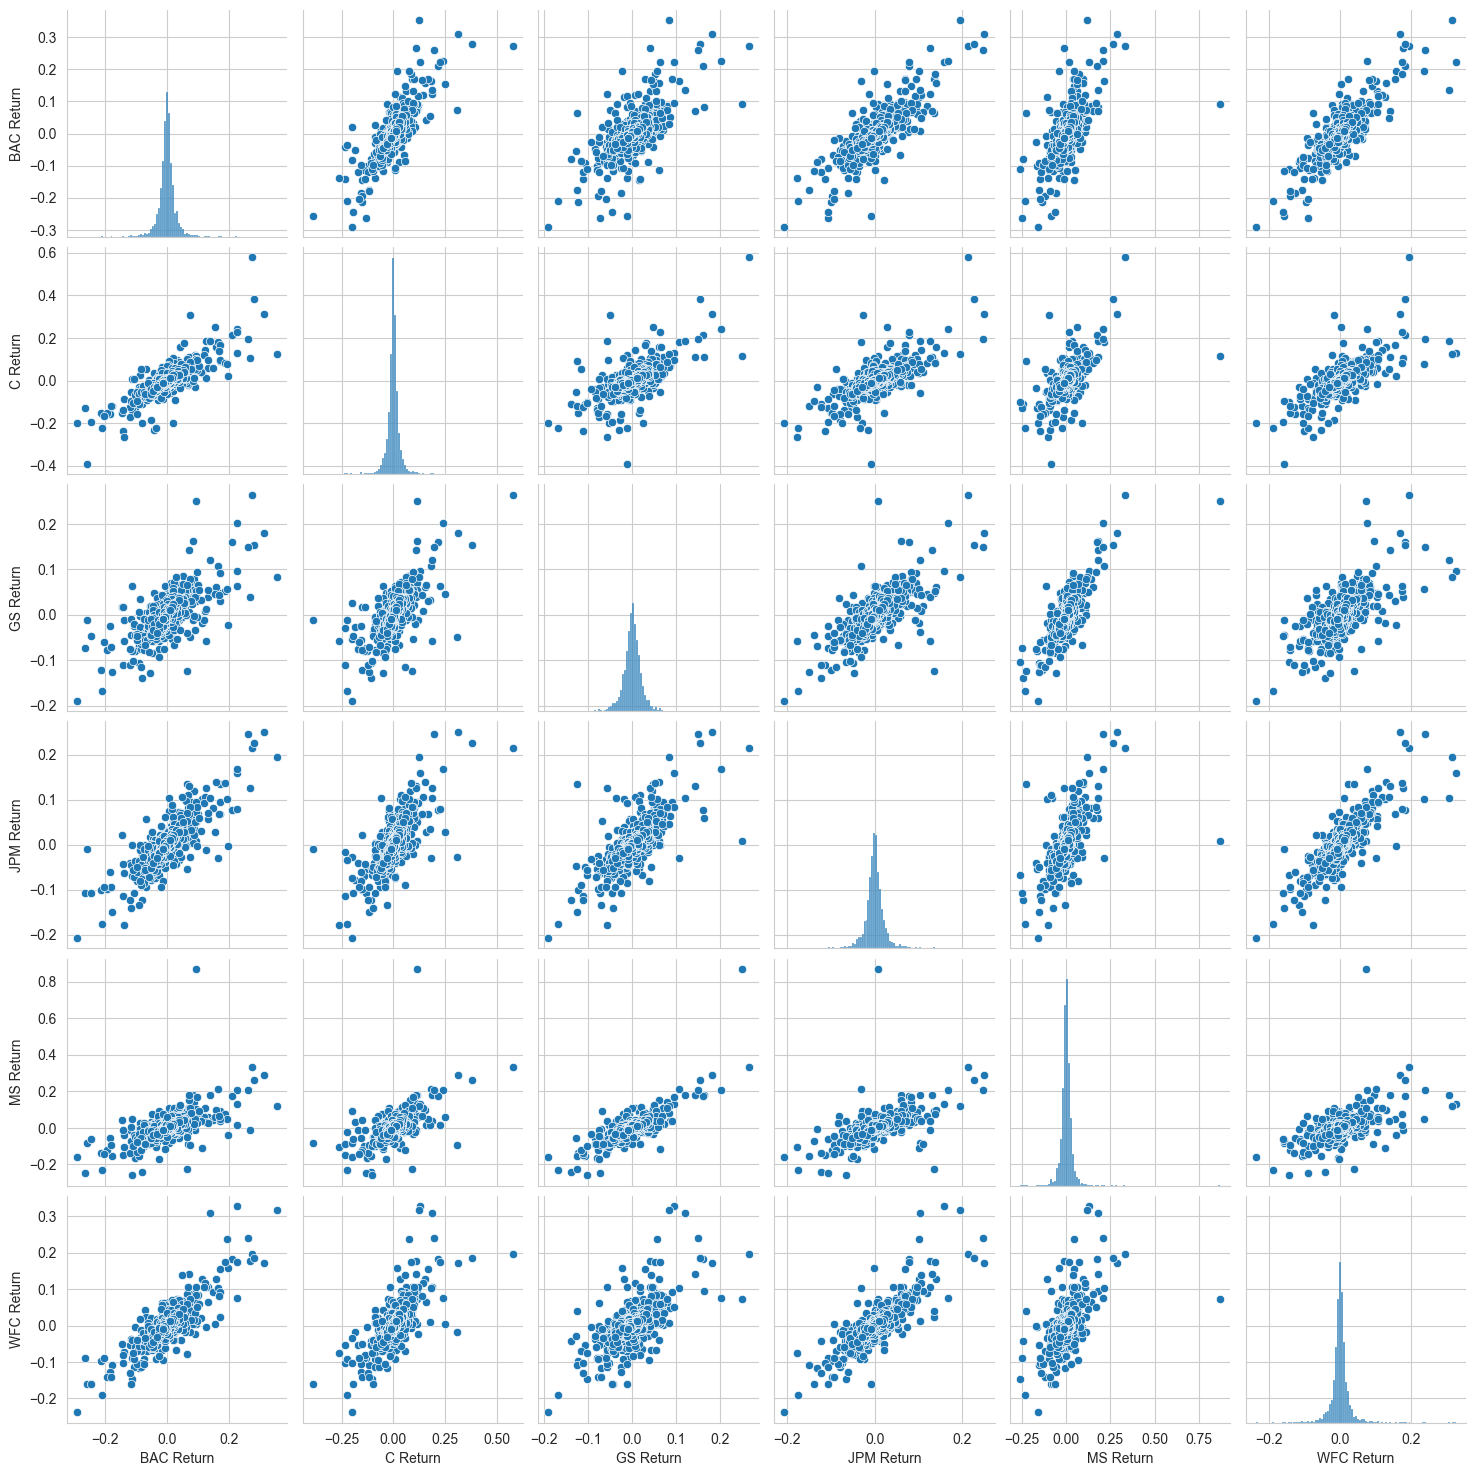

In [22]:
sns.pairplot(returns)

* See solution for details about Citigroup behavior....

** Using this returns DataFrame, figure out on what dates each bank stock had the best and worst single day returns. You should notice that 4 of the banks share the same day for the worst drop, did anything significant happen that day?**

In [23]:
returns.idxmax()

BAC Return   2009-04-09
C Return     2008-11-24
GS Return    2008-11-24
JPM Return   2009-01-21
MS Return    2008-10-13
WFC Return   2008-07-16
dtype: datetime64[s]

** You should have noticed that Citigroup's largest drop and biggest gain were very close to one another, did anythign significant happen in that time frame? **

* See Solution for details

In [24]:
returns.idxmin()

BAC Return   2009-01-20
C Return     2009-02-27
GS Return    2009-01-20
JPM Return   2009-01-20
MS Return    2008-10-09
WFC Return   2009-01-20
dtype: datetime64[s]

** Take a look at the standard deviation of the returns, which stock would you classify as the riskiest over the entire time period? Which would you classify as the riskiest for the year 2015?**

In [25]:
returns.loc['2015-01-01':'2015-12-31'].std()

BAC Return    0.016174
C Return      0.015288
GS Return     0.014043
JPM Return    0.014006
MS Return     0.016287
WFC Return    0.012552
dtype: float64

** Create a distplot using seaborn of the 2015 returns for Morgan Stanley **

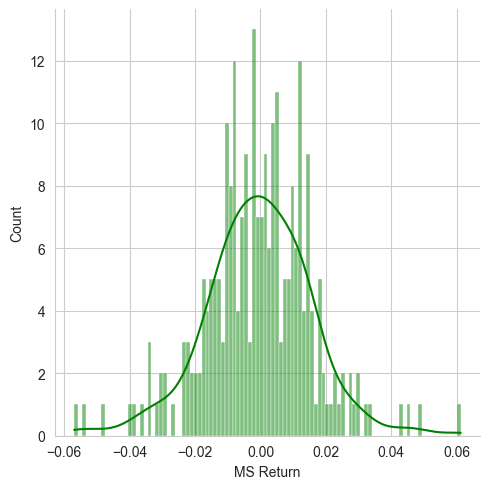

In [26]:
sns.displot(returns.loc['2015']['MS Return'], bins=100, kde=True,color='green')

** Create a distplot using seaborn of the 2008 returns for CitiGroup **

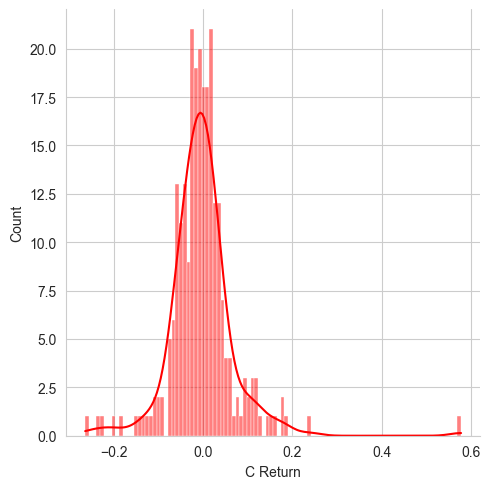

In [27]:
sns.displot(returns['C Return']['2008'], bins=100, kde=True,color='red')

____
# More Visualization

A lot of this project will focus on visualizations. Feel free to use any of your preferred visualization libraries to try to recreate the described plots below, seaborn, matplotlib, plotly and cufflinks, or just pandas.

### Imports

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

# Optional Plotly Method Imports
import plotly
import cufflinks as cf
cf.go_offline()

** Create a line plot showing Close price for each bank for the entire index of time. (Hint: Try using a for loop, or use [.xs](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.xs.html) to get a cross section of the data.)**

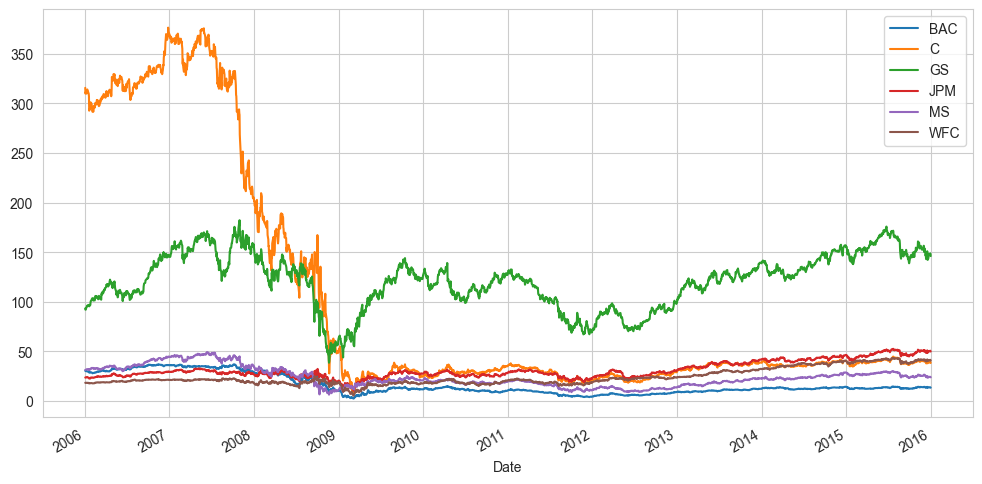

In [29]:
bank_stocks.xs('Close', axis=1, level='Stock Info').plot(figsize=(12,6))
plt.legend(tickers)

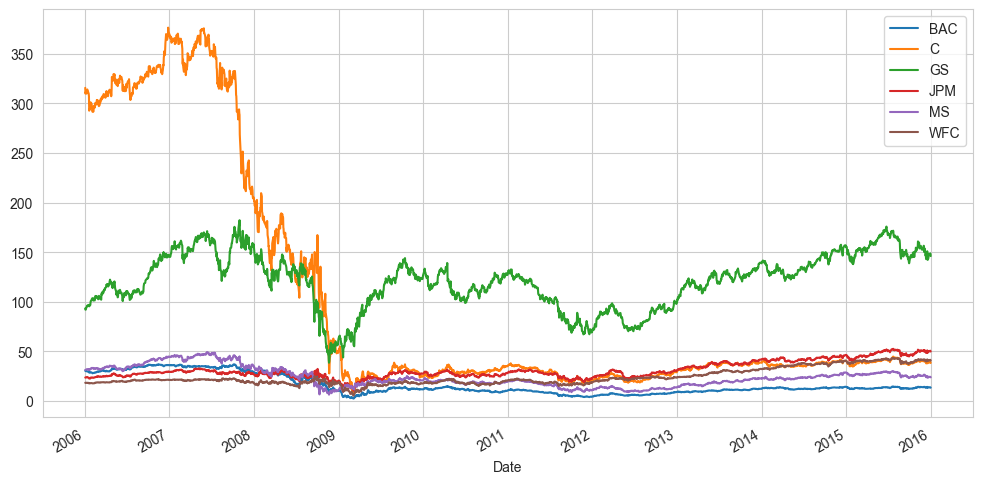

In [ ]:
bank_stocks.xs('Close', axis=1, level='Stock Info').plot(figsize=(12,6))
plt.legend(tickers)

<Figure size 1200x600 with 0 Axes>

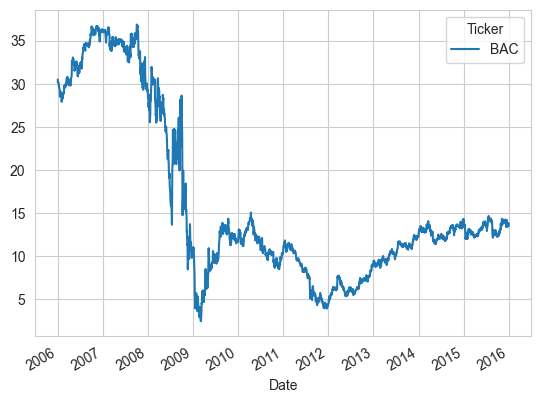

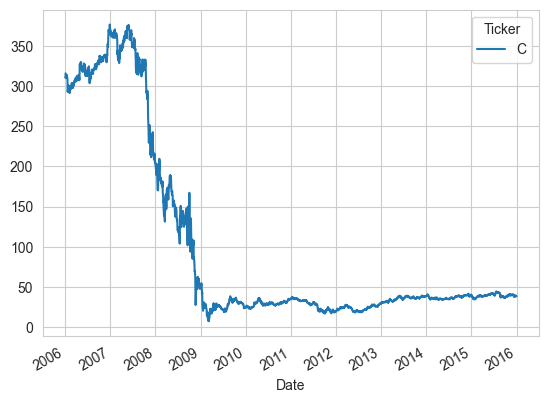

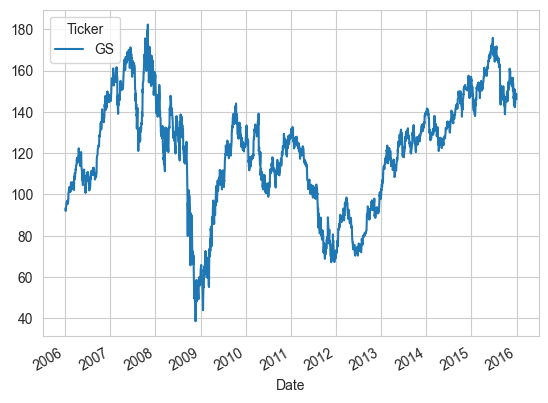

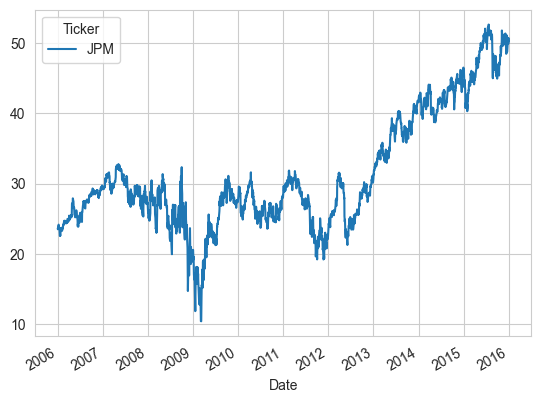

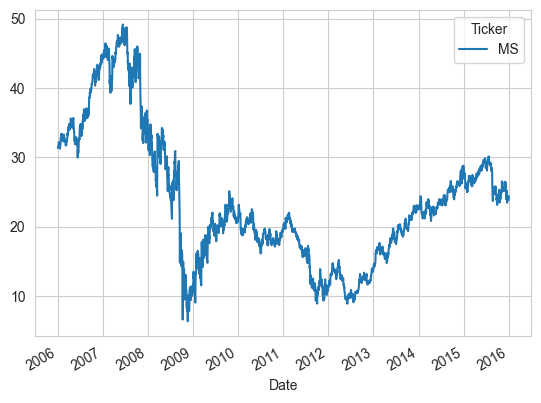

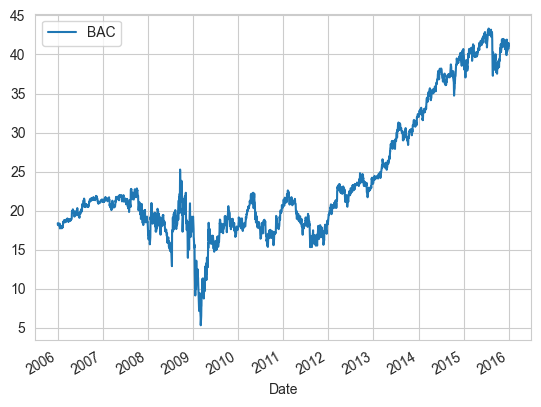

In [30]:

plt.figure(figsize=(12,6))

for tick in tickers:
    bank_stocks[tick]['Close'].plot()

plt.legend(tickers)
plt.show()


## Moving Averages

Let's analyze the moving averages for these stocks in the year 2008. 

** Plot the rolling 30 day average against the Close Price for Bank Of America's stock for the year 2008**

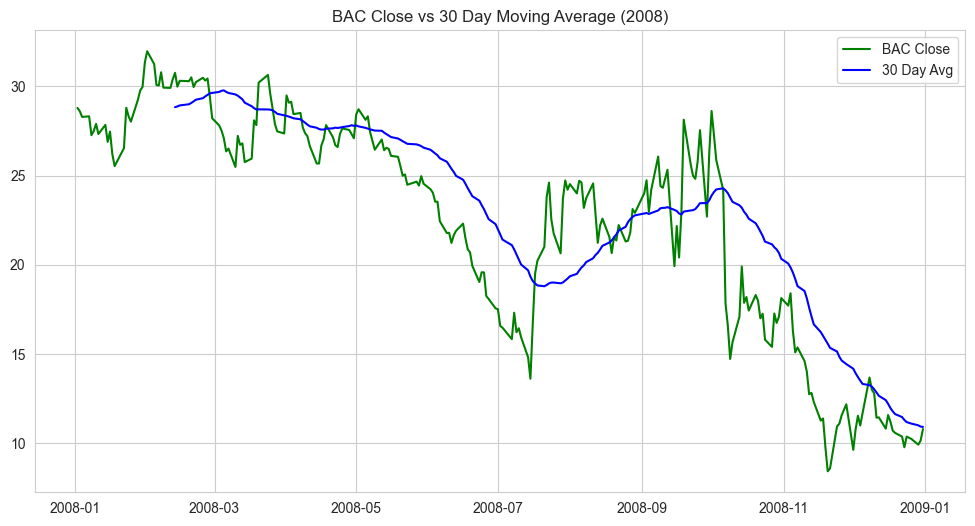

In [30]:
import matplotlib.pyplot as plt
BAC_2008 = bank_stocks['BAC']['Close'].loc['2008']
plt.figure(figsize=(12,6))
plt.plot(BAC_2008.index, BAC_2008, color='green', label='BAC Close')
plt.plot(BAC_2008.index, BAC_2008.rolling(30).mean(), color='blue', label='30 Day Avg')
plt.legend()
plt.title("BAC Close vs 30 Day Moving Average (2008)")
plt.show()


** Create a heatmap of the correlation between the stocks Close Price.**

Text(0.5, 1.0, 'Correlation Heatmap of Bank Close Prices')

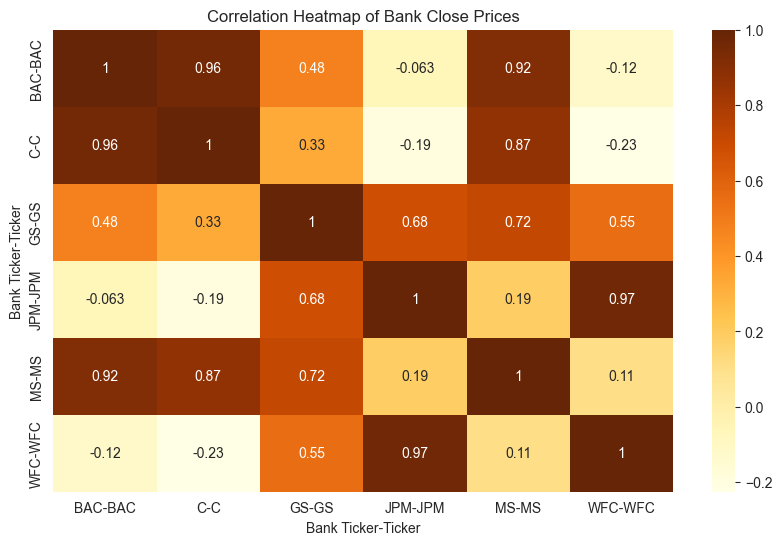

In [31]:
close_df = bank_stocks.xs('Close', axis=1, level='Stock Info')
plt.figure(figsize=(10,6))
sns.heatmap(close_df.corr(), annot=True, cmap='YlOrBr')
plt.title("Correlation Heatmap of Bank Close Prices")

** Optional: Use seaborn's clustermap to cluster the correlations together:**

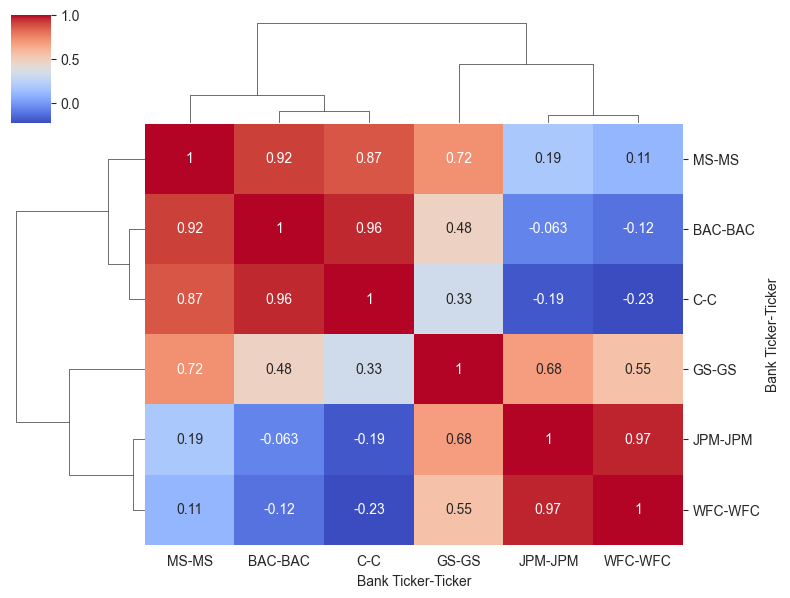

In [ ]:
close_df = bank_stocks.xs('Close', axis=1, level='Stock Info')
sns.clustermap(close_df.corr(), annot=True, cmap='Y', figsize=(8,6))

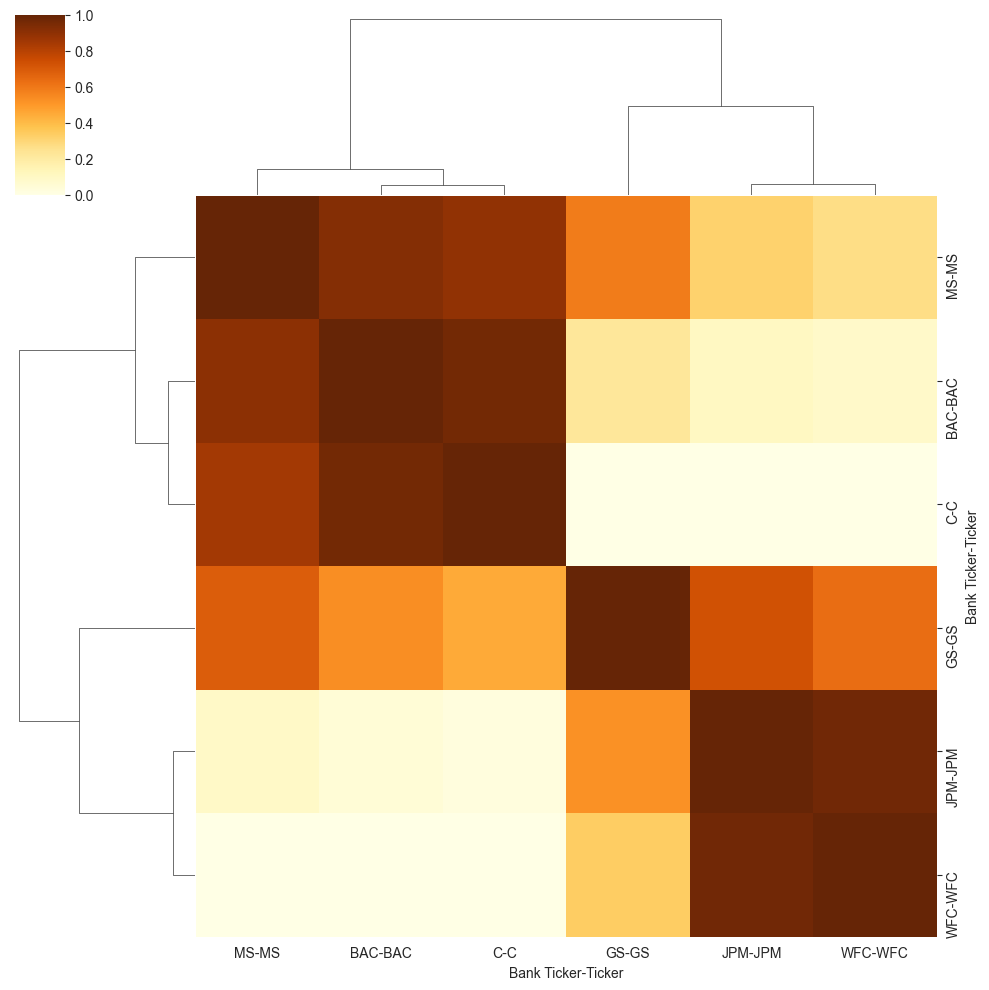

In [39]:


# Close prices extract karo
close_df = bank_stocks.xs('Close', axis=1, level='Stock Info')

# Clustermap
sns.clustermap(close_df.corr(), cmap='YlOrBr', standard_scale=1)


# Part 2 (Optional)

In this second part of the project we will rely on the cufflinks library to create some Technical Analysis plots. This part of the project is experimental due to its heavy reliance on the cuffinks project, so feel free to skip it if any functionality is broken in the future.

** Use .iplot(kind='candle) to create a candle plot of Bank of America's stock from Jan 1st 2015 to Jan 1st 2016.**

In [50]:
BAC_2015 = bank_stocks['BAC'].loc['2015-01-01':'2016-01-01']



In [54]:
print(BAC_2015.head())


                 Open       High        Low      Close     Volume
Date                                                             
2015-01-02  14.123798  14.226374  13.950210  14.194812   48951100
2015-01-05  13.713498  14.052785  13.642486  14.037006  105605500
2015-01-06  13.303201  13.760843  13.240078  13.745062  144912400
2015-01-07  13.366322  13.555691  13.311089  13.524128  104603800
2015-01-08  13.642490  13.681942  13.492572  13.539914   73388500


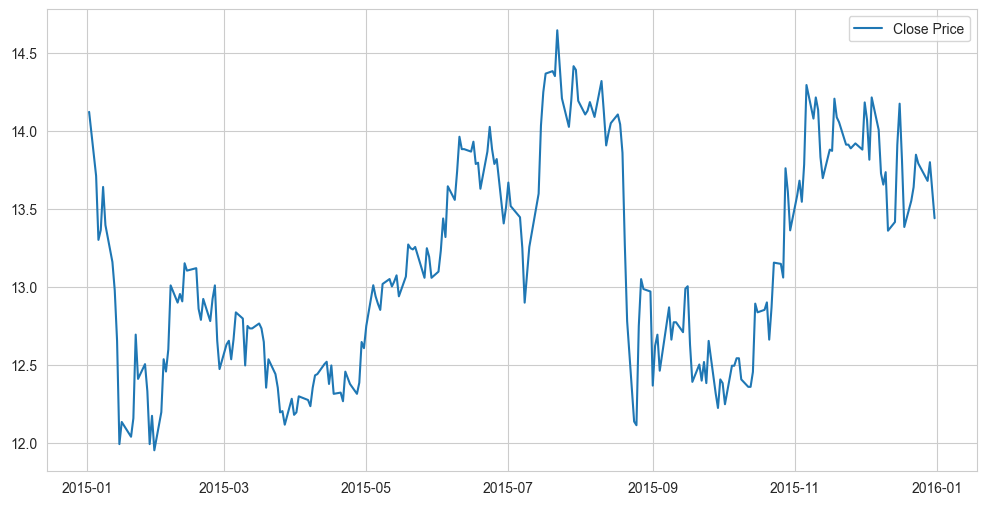

In [55]:
import matplotlib.pyplot as plt

BAC_2015 = bank_stocks['BAC'].loc['2015-01-01':'2016-01-01']

plt.figure(figsize=(12,6))

plt.plot(BAC_2015.index, BAC_2015['Close'], label='Close Price')

plt.legend()
plt.show()


** Use .ta_plot(study='sma') to create a Simple Moving Averages plot of Morgan Stanley for the year 2015.**

# Great Job!

Definitely a lot of more specific finance topics here, so don't worry if you didn't understand them all! The only thing you should be concerned with understanding are the basic pandas and visualization oeprations.